In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures

In [4]:
df = pd.read_csv("Datasets/SalaryGrowth.csv")
df.head()

,Years of Experience,Number of Projects,Salary
0,1,1,25000
1,2,2,30000
2,3,2,35000
3,4,3,45000
4,5,3,50000


In [5]:
df.isna().sum()

Years of Experience    0
Number of Projects     0
Salary                 0
dtype: int64

In [7]:
y = df[["Salary"]]
X = df[["Years of Experience","Number of Projects"]]

In [14]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [15]:
model = LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
y_pred_line = model.predict(x_test)
y_pred_line

array([[79310.34482759],
       [32068.96551724],
       [60517.24137931]])

In [19]:
degree = 2
poly = PolynomialFeatures(degree=degree)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.fit_transform(x_test)

In [20]:
x_train_poly

array([[  1.,   1.,   1.,   1.,   1.,   1.],
       [  1.,   8.,   5.,  64.,  40.,  25.],
       [  1.,   3.,   2.,   9.,   6.,   4.],
       [  1.,  10.,   6., 100.,  60.,  36.],
       [  1.,   5.,   3.,  25.,  15.,   9.],
       [  1.,   4.,   3.,  16.,  12.,   9.],
       [  1.,   7.,   4.,  49.,  28.,  16.]])

In [21]:
model_poly = LinearRegression()
model_poly.fit(x_train_poly,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
y_pred_poly = model_poly.predict(x_test_poly)
y_pred_poly

array([[81304.34782609],
       [33260.86956522],
       [58913.04347826]])

In [25]:
print("Polynomial Regression MSE:", mean_squared_error(y_test, y_pred_poly))

Polynomial Regression MSE: 4505356.017643432


In [26]:
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_line))

Linear Regression MSE: 1674593.7376139546


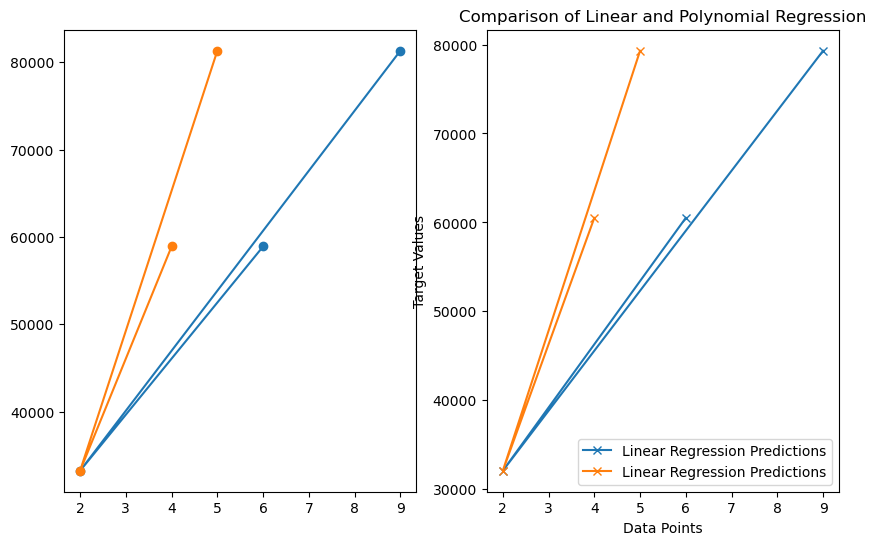

In [37]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.plot(x_test,y_pred_poly, label='Polynomial Regression Predictions', marker='o')
plt.subplot(1,2,2)
plt.plot(x_test,y_pred_line, label='Linear Regression Predictions', marker='x')
plt.xlabel('Data Points')
plt.ylabel('Target Values')
plt.title('Comparison of Linear and Polynomial Regression')
plt.legend()
plt.show()
